37.63870192307692 19.063469199764796


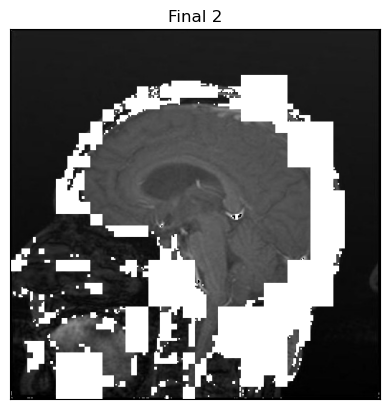

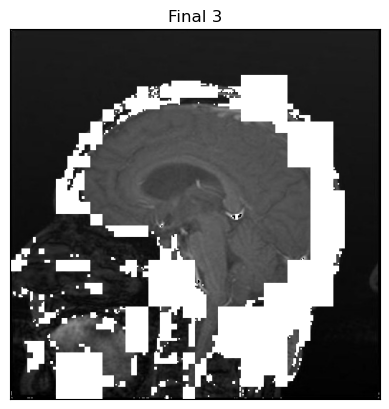

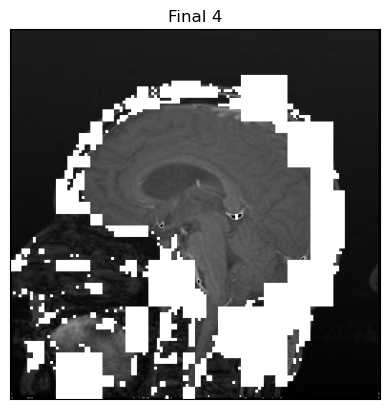

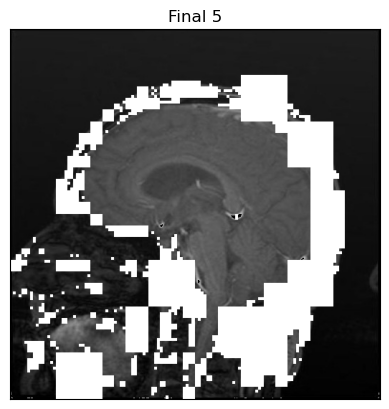

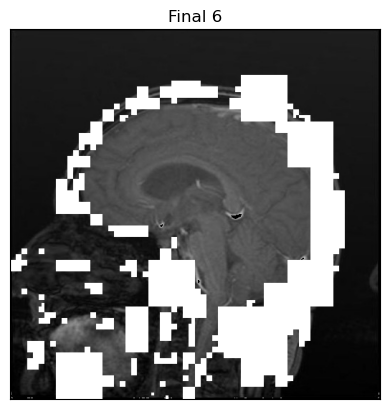

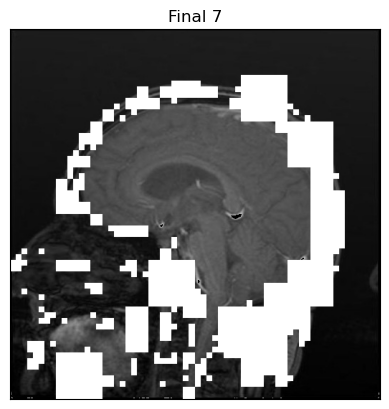

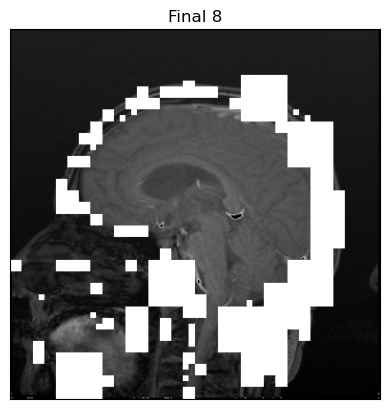

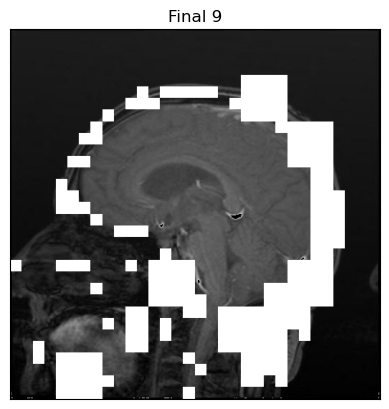

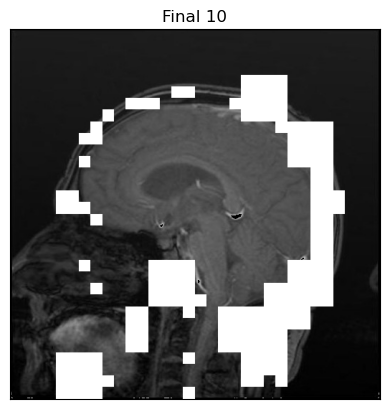

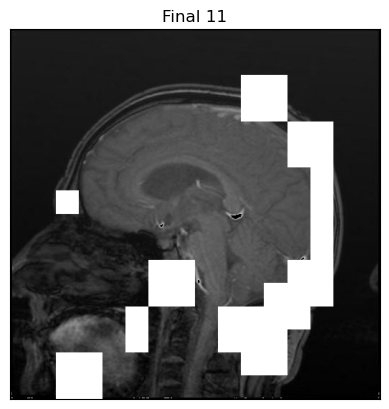

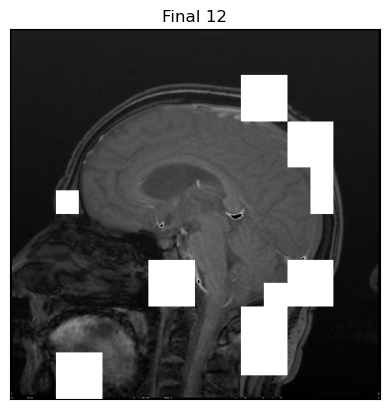

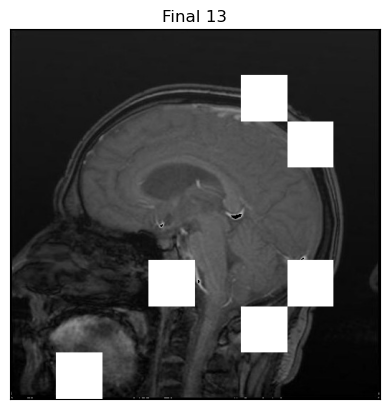

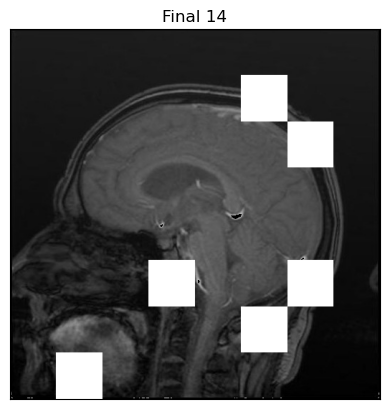

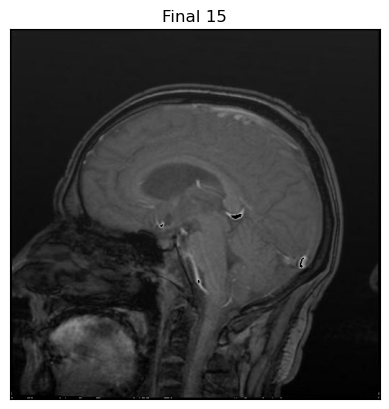

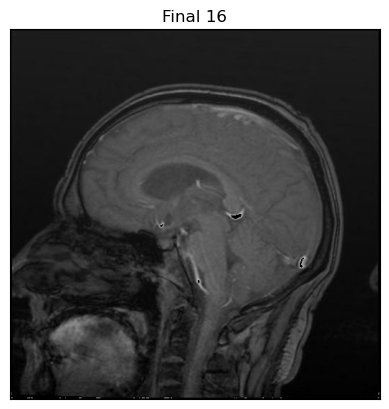

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import math

a = 5
b = 53.5
c = 44


def show_with_plot(img, title):
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    plt.figure()
    plt.imshow(img)
    plt.xticks([])
    plt.yticks([])
    plt.title(title)
    plt.show()


counter = 0    # Figure out the average intensity of the region of interest
def split_and_merge(power, split):
    global counter
    h = split.shape[0]
    w = split.shape[1]
    # if w * h > 1024:
    #     print(w * h)
    if w * h == 4160:
        counter += 1
    sigma = split.std()
    m = split.mean()
    Q = sigma > a and b > m > c
    if counter == 4 and h * w == 4160:
        print(m, sigma)
    if Q and w * h <= 5000:
        split[:, :] = 255
        return
    if h*w <= math.pow(2, power):
        return
    split_and_merge(power, split[:h//2, :w//2])
    split_and_merge(power, split[:h//2, w//2:])
    split_and_merge(power, split[h//2:, :w//2])
    split_and_merge(power, split[h//2:, w//2:])


for i in range(2, 17):
    img = cv.imread('fMRI.jpg')
    img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img[np.where(img >= 190)] = 0   # making the borders black
    split_and_merge(i, img)
    show_with_plot(img, 'Final ' + str(i))
